# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'ratchev2'  # <-- set this
d = np.genfromtxt(f'../../labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.44 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

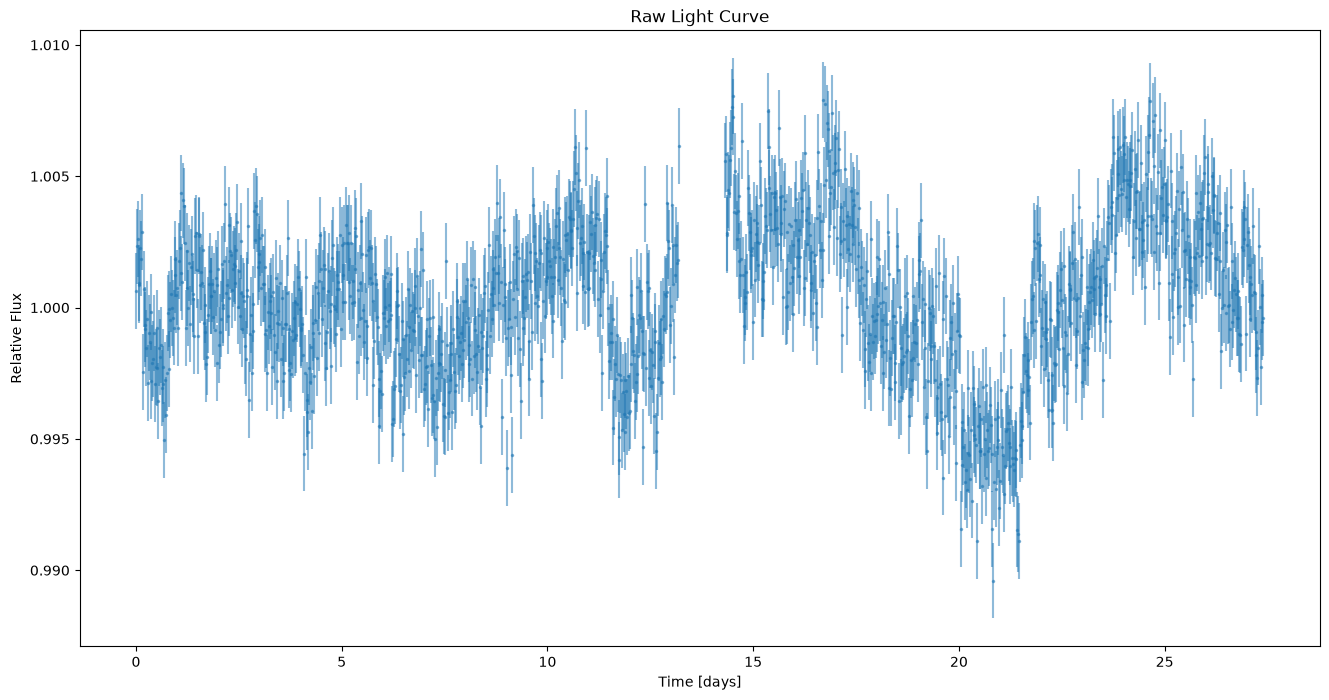

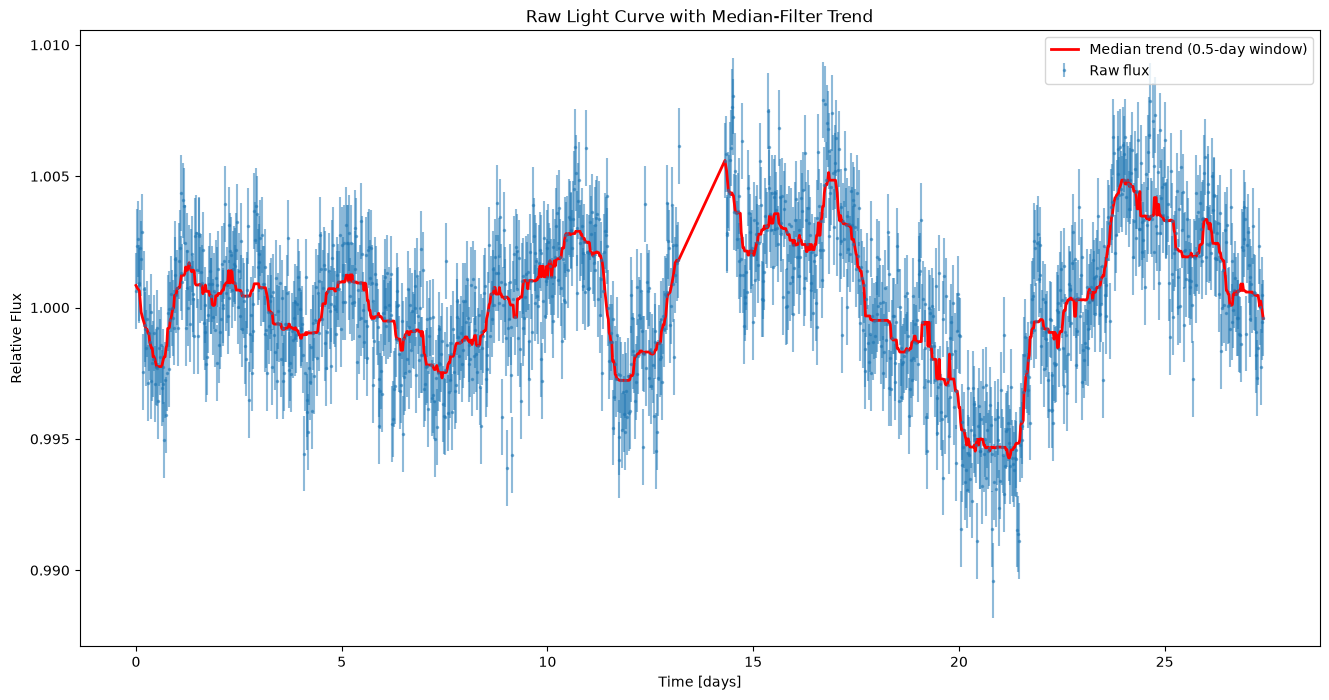

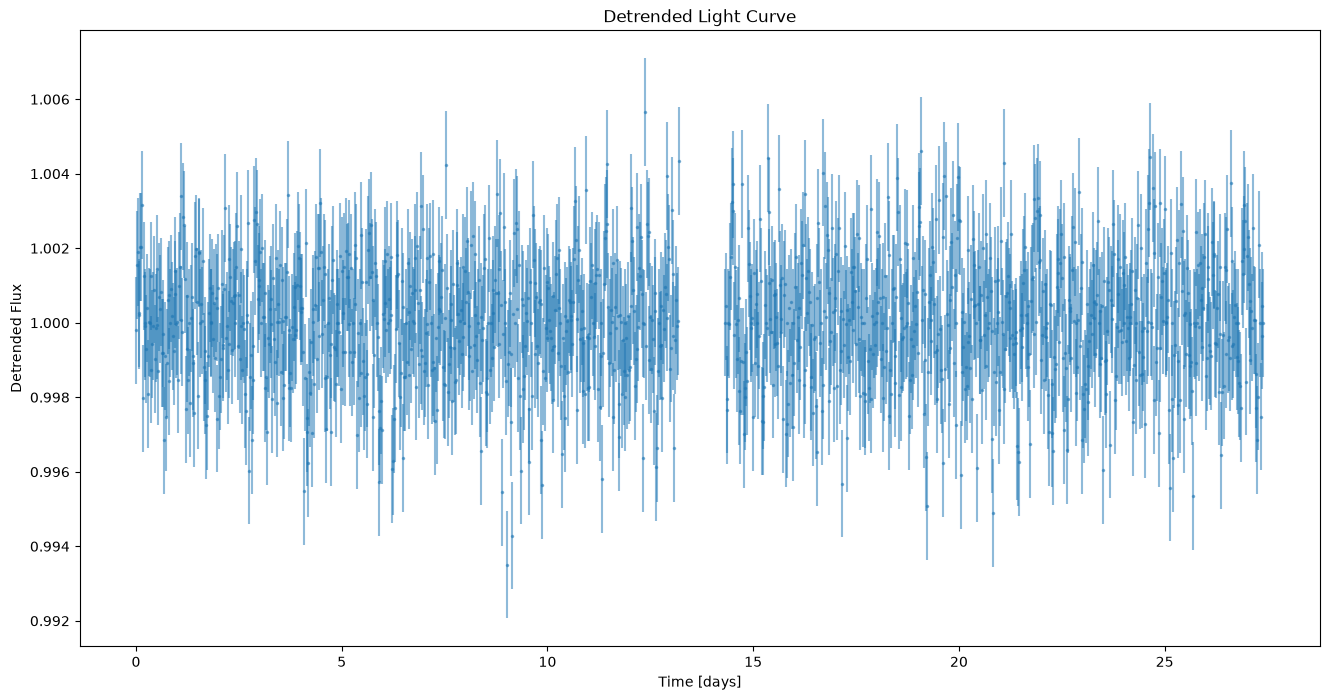

Out-of-transit scatter: 1.63223 ppt
Stated sigma_flux: 1.44332 ppt


In [12]:
# Part 1: your work here
import pandas as pd

# 1: RAW CURVE
plt.figure(figsize=(16, 8))
plt.errorbar(t, flux, yerr = sigma, fmt=".", ms=3, alpha=0.5)
plt.xlabel("Time [days]") 
plt.ylabel("Relative Flux")
plt.title("Raw Light Curve")
plt.show()


# 2: DETREND CURVE
gap_idx= np.argmax(np.diff(t))
seg1 = np.arange(0, gap_idx + 1)
seg2 = np.arange(gap_idx + 1, len(t))

window_size = int(0.5* 48)
trend = np.zeros(len(flux))

for seg in [seg1, seg2]:
    for idx, true_idx in enumerate(seg):
        seg_window = seg[max(0, idx - window_size // 2): min(len(seg), idx + window_size // 2 + 1)]
        trend[true_idx] = np.median(flux[seg_window])



detrended = flux / trend
sigma_detrended = sigma / trend
plt.figure(figsize=(16, 8))
plt.errorbar(t, flux, yerr = sigma, fmt='.', ms = 3, alpha = 0.5, label='Raw flux')
plt.plot(t, trend, color='red', lw=2, label='Median trend (0.5-day window)')
plt.xlabel('Time [days]')
plt.ylabel('Relative Flux')
plt.title('Raw Light Curve with Median-Filter Trend')
plt.legend()
plt.show()


plt.figure(figsize=(16,8))
plt.errorbar(t, detrended, yerr = sigma_detrended, fmt='.', ms=3, alpha=0.5)
plt.xlabel('Time [days]')
plt.ylabel('Detrended Flux')
plt.title('Detrended Light Curve')
plt.show()

t0_guess = 2.8
P_guess = 3.1
T_guess = 0.1

transit_time = ((t - t0_guess + P_guess / 2) % P_guess) - P_guess / 2
out_transit = np.abs(transit_time) > T_guess

scatter_out = np.std(detrended[out_transit], ddof=1)
sigma_out = np.median(sigma_detrended[out_transit])

print("Out-of-transit scatter:", round(scatter_out * 1000, 5), "ppt")
print("Stated sigma_flux:", round(sigma_out * 1000, 5), "ppt")

**ANSWERS (initial guesses + scatter check):**

From the initial data I was able to see a period/t0 which was buried much more in other data for some of the transits. The most clear dips to me are at 2.8 days, 5.9-6, 15.2, and 21.5 which account for the guesses I will make of a t0 of 2.8 days and a period of 3.1 days. I then decided to detrend the light curve using a window median filter with a scale of 0.5 days. I chose this because the median is robust against outliers, and the 0.5 days is multiple times the apparent length of the transits which appears to be about 0.1 days by inspection, meaning that the dips due to the planet do not move the median trend very noticeably. From this detrended graph I could read off the t0 of 2.8 days and period of 3.1 days, along with a length of transit of about 0.1 days and a depth of about 0.003. In order to read these values, I played around with plt.xlim quite a bit due to how short the transits appear to be.

The out-of-transit scatter is slightly larger than the stated sigma_flux which indicates that the noise is slightly larger than the given white-noise uncertainties and that there is some additional systematic noise. I will investigate this further in Part 2.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

Likelihood fit (no uncertainty calculation yet):
t0:  2.821665
P:  3.103194
Delta:  0.002261
T:  0.083788
F0:  1.000043


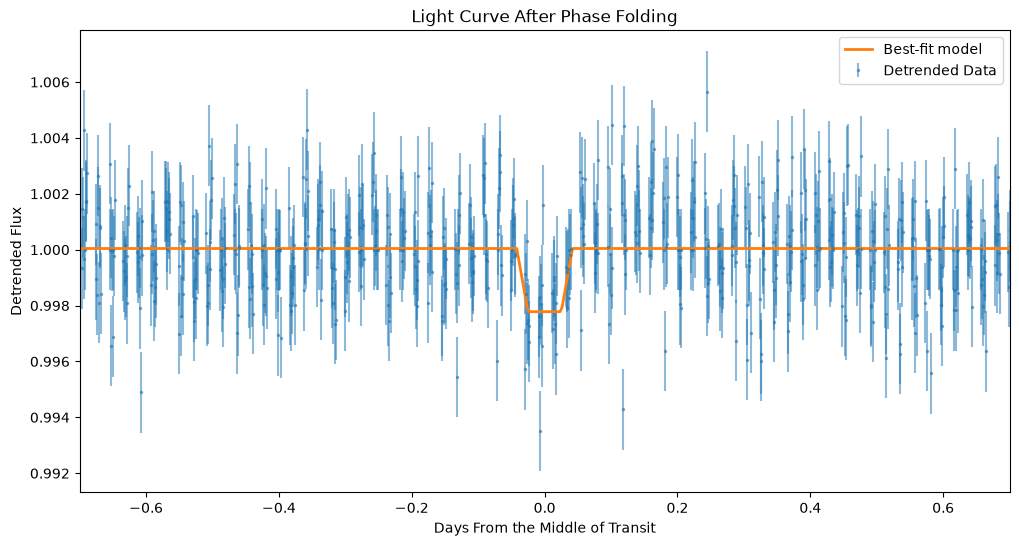

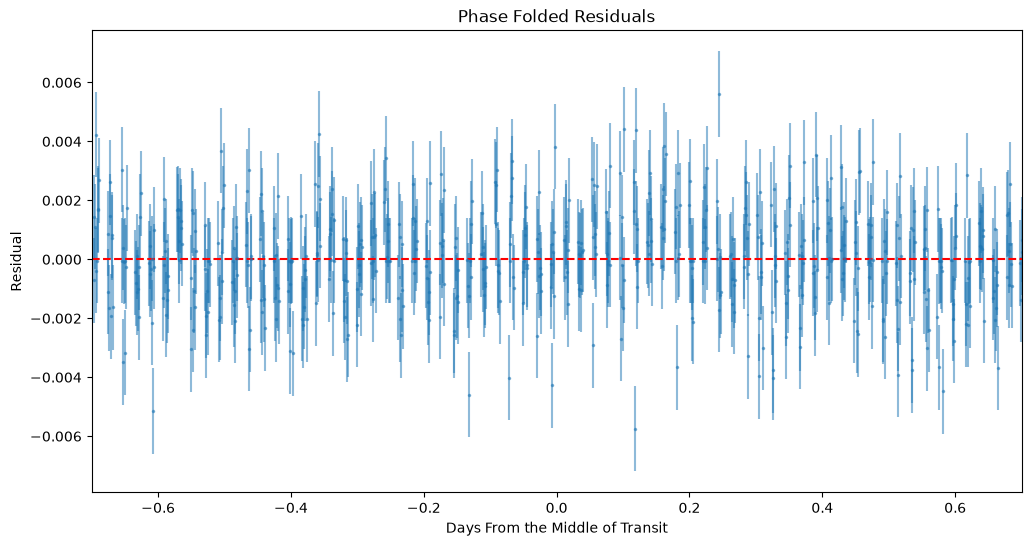


Uncertainties through Inverse Hessian
t0:  2.821665 +/- 0.002903
P:  3.103194 +/- 0.000852
Delta:  0.002261 +/- 0.000311
T:  0.083788 +/- 0.005085
F0:  1.000043 +/- 4.1e-05

Uncertainties through Pointwise Bootstrapping
t0:  2.821665 +/- 0.007153
P:  3.103194 +/- 0.001844
Delta:  0.002261 +/- 0.000377
T:  0.083788 +/- 0.008007
F0:  1.000043 +/- 4.4e-05

Uncertainties through Block Bootstrapping (1 Day Blocks)
t0:  2.821665 +/- 0.008176
P:  3.103194 +/- 0.003724
Delta:  0.002261 +/- 0.000366
T:  0.083788 +/- 0.007024
F0:  1.000043 +/- 4.3e-05


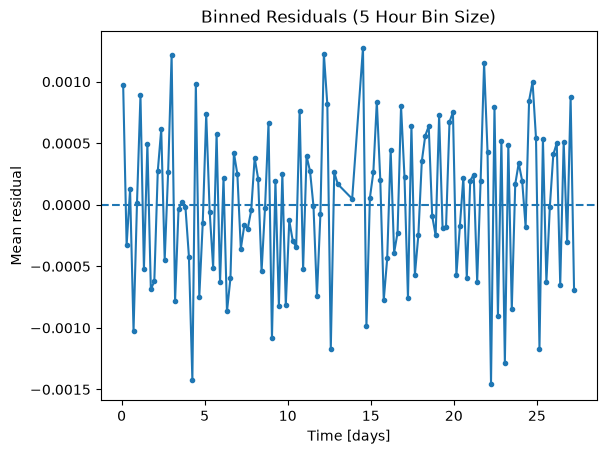

Residuals 5-hour binned scatter: 0.000621
Residuals expected scatter for independent noise: 0.000514
Ratio: 1.207402


In [3]:
# Part 2: your work here
t0_guess = 2.8    
P_guess = 3.1  
delta_guess = 0.003
T_guess = 0.1   
F0_guess = 1.0   

from scipy.optimize import minimize

z0 = [t0_guess, P_guess, delta_guess, T_guess, F0_guess]

def neg_log_likelihood(z0):
    t0, P, delta, T, F0 = z0
    model = transit_model(t, t0, P, delta, T, F0)
    return np.sum((detrended - model)**2 / sigma_detrended**2 + np.log(2 * np.pi * sigma_detrended**2))

t0_fit, P_fit, Delta_fit, T_fit, F0_fit = minimize(neg_log_likelihood, z0, method = 'Nelder-Mead').x
print("Likelihood fit (no uncertainty calculation yet):")
print("t0: ", round(t0_fit, 6))
print("P: ", round(P_fit, 6))
print("Delta: ", round(Delta_fit, 6))
print("T: ", round(T_fit, 6))
print("F0: ", round(F0_fit, 6))
#z0 = [t0_fit, P_fit, Delta_fit, T_fit, F0_fit]
#print(neg_log_likelihood(z0))
model_fit = transit_model(t, t0_fit, P_fit, Delta_fit, T_fit, F0_fit)
# plt.figure(figsize=(16, 6))
# plt.errorbar(t, detrended, yerr = sigma_detrended, fmt='.', ms=3, alpha=0.5, label = "Detrended data")
# plt.plot(t, model_fit, lw=2, label='Best-fit model')

# plt.xlabel("Time [days]")
# plt.ylabel("Detrended Flux")
# plt.title("Best-Fit Transit Model (Using Minimization of Gaussian Log-Likelihood)")
# plt.legend()
# plt.show()

phase = ((t - t0_fit + 0.5 * P_fit) % P_fit) - 0.5 * P_fit
plt.figure(figsize=(12, 6))

plt.errorbar(phase, detrended, yerr = sigma_detrended, fmt='.', ms=3, alpha=0.5, label = "Detrended Data")
phase_grid = np.linspace(-P_fit/2, P_fit/2, 1000)
t_grid = t0_fit + phase_grid
model_grid = transit_model(t_grid,t0_fit,P_fit,Delta_fit,T_fit,F0_fit)
plt.plot(phase_grid, model_grid, lw=2, label='Best-fit model')

plt.xlabel("Days From the Middle of Transit")
plt.ylabel("Detrended Flux")
plt.title("Light Curve After Phase Folding")
plt.legend()
plt.xlim(-0.7, 0.7)
plt.show()

# residuals
residuals = detrended - model_fit
plt.figure(figsize=(12, 6))
plt.errorbar(phase, residuals, yerr = sigma_detrended, fmt='.', ms=3, alpha=0.5)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel("Days From the Middle of Transit")
plt.ylabel("Residual")
plt.title("Phase Folded Residuals")
plt.xlim(-0.7, 0.7)
plt.show()

# Hessian uncertainty
res = minimize(neg_log_likelihood, z0, method = 'Nelder-Mead')
h = 1e-4
n = len(res.x)
hess = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h; ej[j] = h
        hess[i, j] = (neg_log_likelihood(res.x + ei + ej) - neg_log_likelihood(res.x + ei - ej)
                          - neg_log_likelihood(res.x - ei + ej) + neg_log_likelihood(res.x - ei - ej)) / (4 * h**2)
errors = np.sqrt(np.diag(2 * np.linalg.inv(hess)))
print("")
print("Uncertainties through Inverse Hessian")
print("t0: ", round(t0_fit, 6), "+/-", round(errors[0], 6))
print("P: ", round(P_fit, 6), "+/-", round(errors[1], 6))
print("Delta: ", round(Delta_fit, 6), "+/-", round(errors[2], 6))
print("T: ", round(T_fit, 6), "+/-", round(errors[3], 6))
print("F0: ", round(F0_fit, 6), "+/-", round(errors[4], 6))

# Individual Point Bootstrap
def neg_log_likelihood_boot(z0, t, detrended, sigma_detrended):
    t0, P, delta, T, F0 = z0
    model = transit_model(t, t0, P, delta, T, F0)
    return np.sum((detrended - model)**2 / sigma_detrended**2 + np.log(2 * np.pi * sigma_detrended**2))
    
rng = np.random.default_rng(100000)
boot_num = 1000

t0_boot_arr = np.empty(boot_num) 
P_boot_arr = np.empty(boot_num) 
Delta_boot_arr = np.empty(boot_num) 
T_boot_arr = np.empty(boot_num) 
F0_boot_arr = np.empty(boot_num)

for i in range(boot_num):
    random_idxs = rng.integers(0, len(t), size=len(t))
    z0 = [t0_fit, P_fit, Delta_fit, T_fit, F0_fit]
    result = minimize(neg_log_likelihood_boot, z0, args = (t[random_idxs], detrended[random_idxs], sigma_detrended[random_idxs]), method = "Nelder-Mead")
    t0_boot_arr[i], P_boot_arr[i], Delta_boot_arr[i], T_boot_arr[i], F0_boot_arr[i] = result.x

sigma_t0_point = np.std(t0_boot_arr, ddof = 1)
sigma_P_point = np.std(P_boot_arr, ddof=1)
sigma_Delta_point = np.std(Delta_boot_arr, ddof=1)
sigma_T_point = np.std(T_boot_arr, ddof=1)
sigma_F0_point = np.std(F0_boot_arr, ddof=1)

print("")
print("Uncertainties through Pointwise Bootstrapping")
print("t0: ", round(t0_fit, 6), "+/-", round(sigma_t0_point, 6))
print("P: ", round(P_fit, 6), "+/-", round(sigma_P_point, 6))
print("Delta: ", round(Delta_fit, 6), "+/-", round(sigma_Delta_point, 6))
print("T: ", round(T_fit, 6), "+/-", round(sigma_T_point, 6))
print("F0: ", round(F0_fit, 6), "+/-", round(sigma_F0_point, 6))

# Block Bootstrap (1 Day)
block_num = int(np.ceil(len(t) / 48))
block_idx = []
for i in range(block_num):
    block_idx.append(np.arange(i * 48, min((i + 1) * 48, len(t))))

t0_block_arr = np.empty(boot_num) 
P_block_arr = np.empty(boot_num) 
Delta_block_arr = np.empty(boot_num) 
T_block_arr = np.empty(boot_num) 
F0_block_arr = np.empty(boot_num)

for i in range(boot_num):
    random_blocks = rng.integers(0, len(block_idx), size=len(block_idx))
    random_idxs = np.concatenate([block_idx[j] for j in random_blocks])
    random_idxs = random_idxs[:len(t)] # just doing this as a check to make sure we dont go over the needed number of points
    z0 = [t0_fit, P_fit, Delta_fit, T_fit, F0_fit]
    result = minimize(neg_log_likelihood_boot, z0, args = (t[random_idxs], detrended[random_idxs], sigma_detrended[random_idxs]), method = "Nelder-Mead")
    t0_block_arr[i], P_block_arr[i], Delta_block_arr[i], T_block_arr[i], F0_block_arr[i] = result.x

sigma_t0_block = np.std(t0_block_arr, ddof = 1)
sigma_P_block = np.std(P_block_arr, ddof=1)
sigma_Delta_block = np.std(Delta_block_arr, ddof=1)
sigma_T_block = np.std(T_block_arr, ddof=1)
sigma_F0_block = np.std(F0_block_arr, ddof=1)

print("")
print("Uncertainties through Block Bootstrapping (1 Day Blocks)")
print("t0: ", round(t0_fit, 6), "+/-", round(sigma_t0_block, 6))
print("P: ", round(P_fit, 6), "+/-", round(sigma_P_block, 6))
print("Delta: ", round(Delta_fit, 6), "+/-", round(sigma_Delta_block, 6))
print("T: ", round(T_fit, 6), "+/-", round(sigma_T_block, 6))
print("F0: ", round(F0_fit, 6), "+/-", round(sigma_F0_block, 6))

# Binned residuals
bin_size = 10
binned_res = np.zeros(len(residuals) // bin_size)
bin_times = np.zeros(len(residuals) // bin_size)
for i in range(len(residuals) // bin_size):
    binned_res[i] = np.mean(residuals[i * bin_size: (i + 1) * bin_size])
    bin_times[i] = np.mean(t[i * bin_size: (i + 1) * bin_size])
bin_scatter = np.std(binned_res, ddof = 1)
single_scatter = np.std(residuals, ddof = 1)
exp_scatter = single_scatter / np.sqrt(bin_size)

plt.plot(bin_times, binned_res, ".-")
plt.axhline(0, linestyle="--")

plt.xlabel("Time [days]")
plt.ylabel("Mean residual")
plt.title("Binned Residuals (5 Hour Bin Size)")
plt.show()

print("Residuals 5-hour binned scatter:", round(bin_scatter, 6))
print("Residuals expected scatter for independent noise:", round(exp_scatter, 6))
print("Ratio:", round(bin_scatter / exp_scatter, 6))


**FINAL ANSWER:** $\delta = $ 2.261 $\pm$ 0.366 ppt, $P = $ 3.103194 $\pm$ 0.003724 d, $t_0 = $ 2.821665 $\pm$ 0.008176 d

**Which uncertainty and why (a short paragraph):**

The inverse-Hessian method gives the smallest uncertainties for most parameters, while both bootstrap methods gave larger uncertainties. The block bootstrap additionally produces substantially larger uncertainties than the pointwise bootstrapping for t0 and the period. The difference between these methods comes from their respective noise assumptions, where both the Hessian and point-wise bootstrap assume that the individual measurements have independent errors. However, with our measured residual ratio as seen above with the binned residuals versus those expected by independent noise being greater than 1, we can see that there are some time correlations between residuals. This causes the Hessian method and the point-wise method to underestimate the uncertainties as they do not account for this, while the block method preserves some of the correlations by sampling in a block like manner (though some is still lost at the edges of the blocks with my current implementation). This is the consistent with the out-of-transit scatter higher than the stated sigma values in part 1, indicating additional noise not measured by the given values. Due to the above argument, the block bootstrap uncertainties are the most appropriate and so I will be using them.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

Flaw 1: The AI solution uses a 6-hour median filter to detrend the light curve. However, the transit (according to my fit) lasts only about 2 hours, and so is a decent chunk of this 6 hour window. This means that the filter may actually "eat" the transits, which is what I avoided by using a window of double this size. We can see in Demonstration 1 how this results in the detrending largely fitting to the first transit (and the others but here I focus on the first) which will down the line result in a smaller measured value of the transit depth than is correct as the transits are "eaten". The correct treatment is to use a sufficiently long detrending window in comparison to the transient length, such as 0.5 days or longer.

Flaw 2: The AI ignores the given measurement uncertainties and uses the scatter to assign its own. This is problematic because the overall scatter is not equivalent to the measurement uncertainty of the observations, and it also includes the transient signal. To demonstrate this in a quantitative way, I again printed out the scatter of my data after detrending excluding the transient as I did in part 1 as well as the measurement uncertainty stated, and compared these values to the value obtained by using the AI method on my data after detrending (here I am "leveling" the playing field by making sure not to consider the previous mistake of the ai and using my own method). We see below in the demonstration that the AI calculation does not provide a clean estimate of the noise not only by being quite off from the stated uncertainties that should be used, but also by failing to consider the fact that the transit will add to the scatter and result in an even higher uncertainty. The correct treatment is to keep the given uncertainties and investigate the excess scatter and correlations instead as I did previously.

Flaw 3: The AI uses a reduced chi-squared near one as proof that its noise model and uncertainty are correct. However, this is not a validation of the AI's noise because the noise estimation is coming from the same exact data that defines chi-squared. Since chi-squared is literally defined in terms of the standard deviation, this means a model in which there is no transits at all and just a flat line at the mean flux will by construction have a chi_2 of 1. This is obviously not the correct model. and so this shows that chi2 is not a valid standalone validation of the AI's noise and uncertainty, and thus this part of its analysis is circular. This is demonstrated explicitly by showing this chi2 of 1 being obtained with a flat model. The AI's actual transit fit gives a reduced chi-squared of 0.977, but this similarly cannot by itself confirm that the uncertainty is correct (after all using its own reasoning, it should have just used the flat model as that has the highest chi2). Additionally, as was shown in Part 2 (so I will not repaste it here), the observed scatter was larger than expected by independent noise when binning in 5 hour windows. This means that the AI's reduced chi-squared of close to one does not confirm the uncertainty as the residuals are not even time independent, and this value can be reproduced just by correlated residuals. The correct treatment was to do a full investigation of the noise correlations as I did in Part 2 with multiple different bootstrap models.

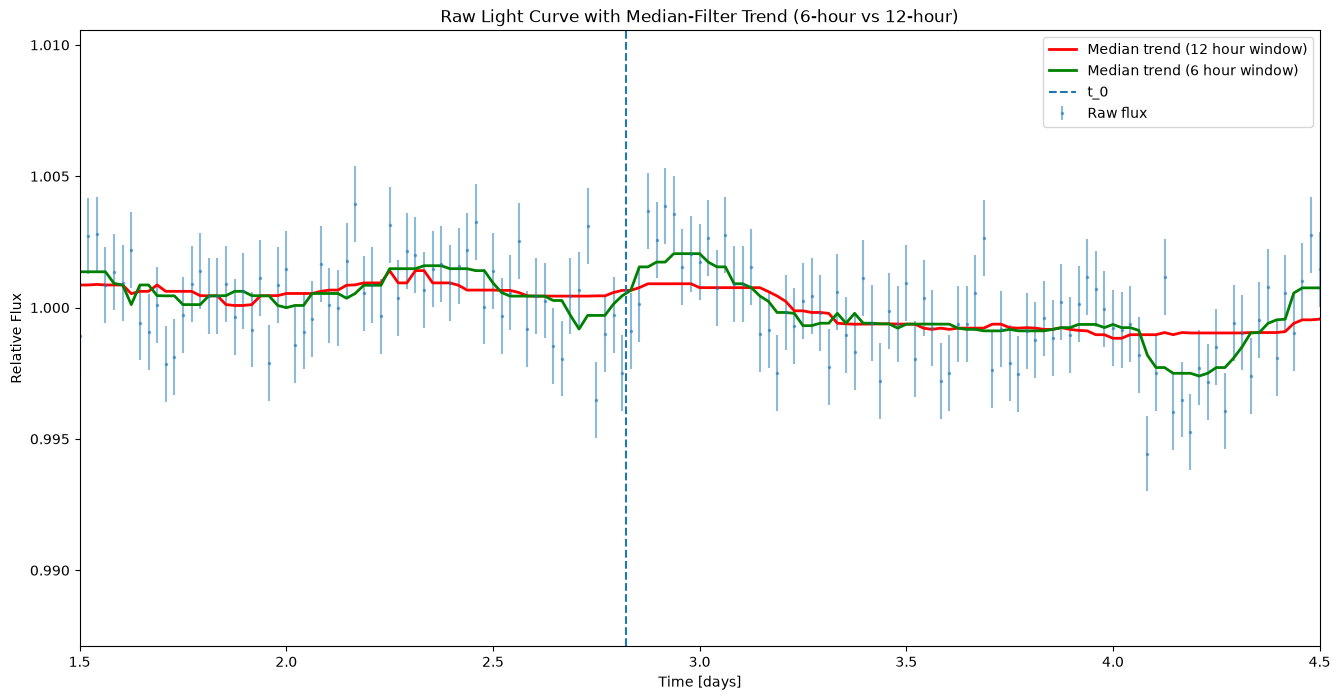

Out-of-transit scatter: 1.63223 ppt
Stated sigma_flux: 1.44332 ppt
AI uncertainty method using my detrending: 1.65394 ppt
Reduced chi-squared for a flat model with no transits: 1.0


In [4]:
# Part 3: demonstrations here

# DEMONSTRATION 1
gap_idx= np.argmax(np.diff(t))
seg1 = np.arange(0, gap_idx + 1)
seg2 = np.arange(gap_idx + 1, len(t))

window_size = int(0.5* 48)
window_size2 = int(0.25* 48)
trend = np.zeros(len(flux))
trend2 = np.zeros(len(flux))
for seg in [seg1, seg2]:
    for idx, true_idx in enumerate(seg):
        seg_window = seg[max(0, idx - window_size // 2): min(len(seg), idx + window_size // 2 + 1)]
        seg_window2 = seg[max(0, idx - window_size2 // 2): min(len(seg), idx + window_size2 // 2 + 1)]
        trend[true_idx] = np.median(flux[seg_window])
        trend2[true_idx] = np.median(flux[seg_window2])



detrended = flux / trend
sigma_detrended = sigma / trend
plt.figure(figsize=(16, 8))
plt.errorbar(t, flux, yerr = sigma, fmt='.', ms = 3, alpha = 0.5, label='Raw flux')
plt.plot(t, trend, color='red', lw=2, label='Median trend (12 hour window)')
plt.plot(t, trend2, color = 'green', lw=2, label='Median trend (6 hour window)')
plt.axvline(t0_fit, ls = '--', label = 't_0')
plt.xlabel('Time [days]') 
plt.ylabel('Relative Flux')
plt.title('Raw Light Curve with Median-Filter Trend (6-hour vs 12-hour)')
plt.legend()
plt.xlim(1.5, 4.5)
plt.show()

# DEMONSTRATION 2

scatter_out = np.std(detrended[out_transit], ddof=1)
sigma_out = np.median(sigma_detrended[out_transit])
sigma_ai = np.std(detrended, ddof = 1)

print("Out-of-transit scatter:", round(scatter_out * 1000, 5), "ppt")
print("Stated sigma_flux:", round(sigma_out * 1000, 5), "ppt")
print("AI uncertainty method using my detrending:", round(sigma_ai * 1000, 5), "ppt")

# DEMONSTRATION 3
resid_flat = detrended - np.mean(detrended)

chi2_flat = np.sum((resid_flat / sigma_ai)**2)
red_chi2_flat = chi2_flat / (len(detrended) - 1)

print("Reduced chi-squared for a flat model with no transits:", red_chi2_flat)

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

I didn't use any. I did look up some terms that I didn't know and referred to what we did in class using Google and found my answer in random websites and papers, but the code is all my own (and the reasoning).

**VERIFICATION PLAN:**

I did multiple checks before deciding to trust my Part 2 results. For one, I used the given period and t0 to calculate where all of the transits should be before doing the phase stacking and made sure that they at least mostly aligned with a dip in the detrended curve I got in Part 1. A failure would have been if the predicted transit times consistently did not coincide with the dips in the light curve. This would suggest that something is wrong with the period/t0 or that there was some issue of units. I also compared the fitted parameters, including the less relevant ones such as the duration of the transit to my initial guesses based on what I could see in the data and made sure they were mostly consistent. A failure would have looked like parameters very different from my guess, which would have indicated that I am not fitting to what I thought was the periodic behavior indicitive of planetary transit. One other big check I did was trying out many different guesses for the initial parameters and printing out the negative log likelihood for each of them. I made sure that the initial parameters I initially guessed were those that resulted in a fit with the most negative result. A failure would have been if other parameters obtained a more negative result, which would have again indicated my idea of the data and where the transits were was completely wrong, and that the initial guess was just a local minima rather than the global one I was looking for. I also spent much more time than I would like to admit trying different window sizes for the detrending and made sure I chose the smallest window that didnt seem to get impacted by the transit dips but also captured the other trends in the data the closest in order to remove them. A failure here would have been if I found that my given window was trend fitting to the transit dips themselves (similar to what the AI model did).